Dataset downloaded to: C:\Users\nikhi\.cache\kagglehub\datasets\blastchar\telco-customer-churn\versions\1
Dataset file: C:\Users\nikhi\.cache\kagglehub\datasets\blastchar\telco-customer-churn\versions\1\WA_Fn-UseC_-Telco-Customer-Churn.csv

First 5 rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL 

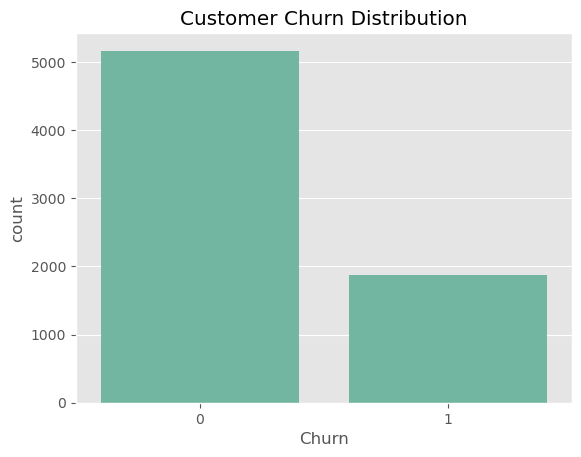


Churn by Contract
Churn              0     1
Contract                  
Month-to-month  2220  1655
One year        1306   166
Two year        1637    48


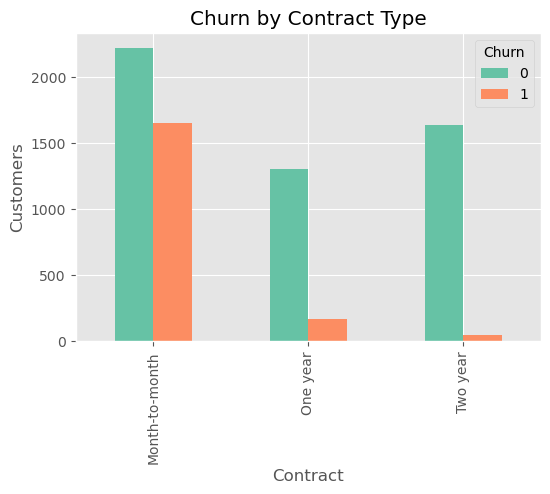


Churn by Internet Service
Churn               0     1
InternetService            
DSL              1957   459
Fiber optic      1799  1297
No               1407   113


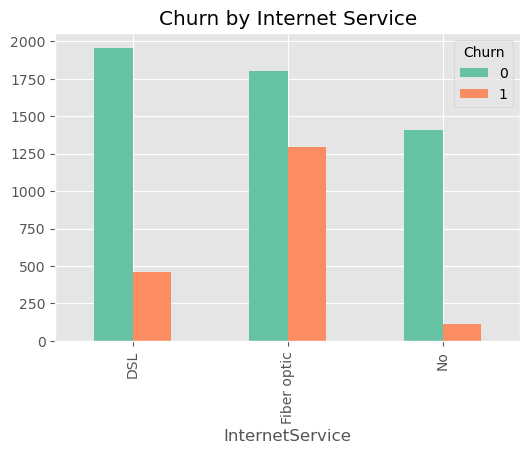


Churn by Payment Method
Churn                         0     1
PaymentMethod                        
Bank transfer (automatic)  1284   258
Credit card (automatic)    1289   232
Electronic check           1294  1071
Mailed check               1296   308


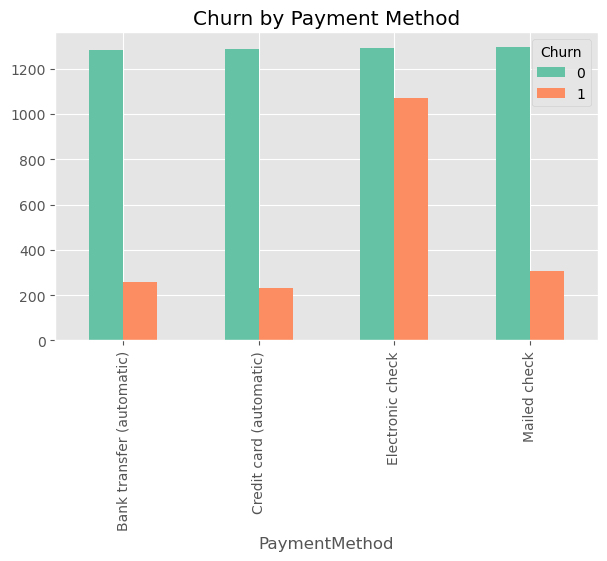

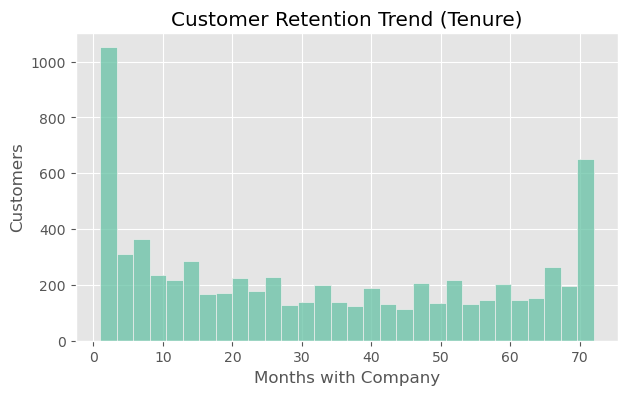


Cohort Analysis (Tenure Groups)
Churn           0     1
TenureGroup            
0-1 Year     1138  1037
1-2 Years     730   294
2-3 Years     652   180
3-4 Years     617   145
4-5 Years     712   120
5-6 Years    1314    93


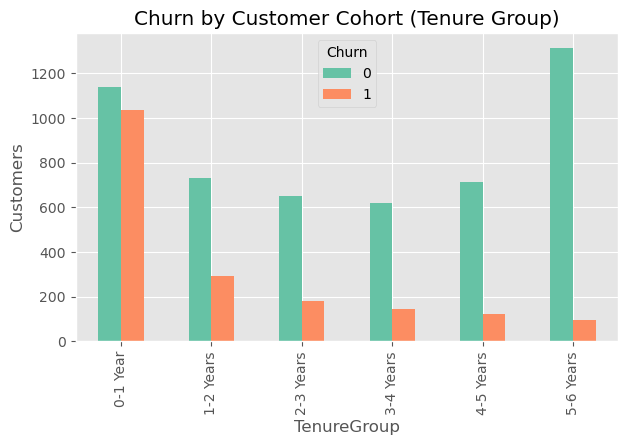


Average Monthly Revenue: 64.8
Average Customer Tenure: 32.42
Estimated Customer Lifetime Value: 2100.87


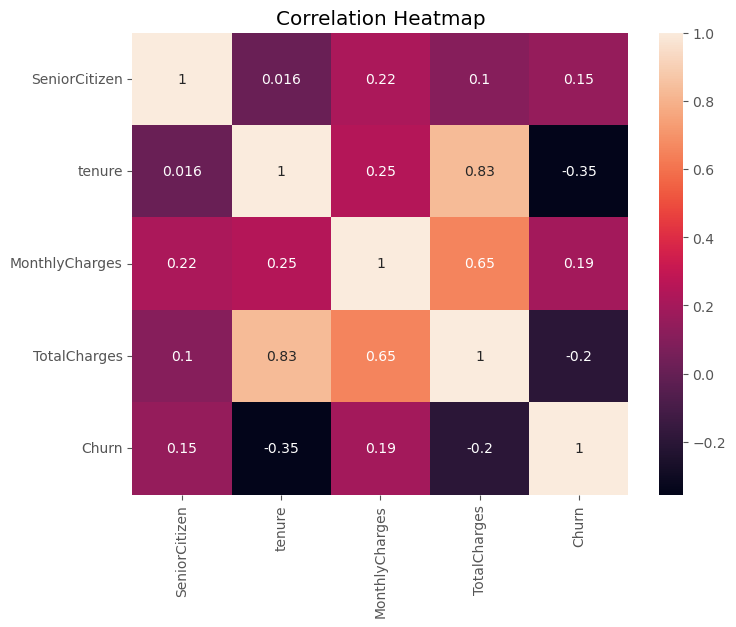


High Risk Customers: 1318

BUSINESS INSIGHTS
1. Month-to-Month contracts have the highest churn.
2. Customers with tenure less than 6 months churn more.
3. Higher monthly charges increase churn probability.
4. Electronic check payment users show higher churn.

BUSINESS RECOMMENDATIONS
• Offer discounts for yearly contracts.
• Improve onboarding for new customers.
• Provide loyalty rewards for long-term customers.
• Improve service quality for high-cost plans.

Customer Retention Analysis Completed!


In [1]:
# =====================================================
# CUSTOMER RETENTION & CHURN ANALYSIS PROJECT
# Future Interns – Data Science Task
# =====================================================

# ------------------------------
# 1. IMPORT LIBRARIES
# ------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os

plt.style.use("ggplot")
sns.set_palette("Set2")

# ------------------------------
# 2. DOWNLOAD DATASET FROM KAGGLE
# ------------------------------

path = kagglehub.dataset_download("blastchar/telco-customer-churn")
print("Dataset downloaded to:", path)

# Find the CSV file inside the folder
for file in os.listdir(path):
    if file.endswith(".csv"):
        dataset_path = os.path.join(path, file)

print("Dataset file:", dataset_path)

# Load dataset
df = pd.read_csv(dataset_path)

print("\nFirst 5 rows:")
print(df.head())

print("\nDataset Shape:", df.shape)

# ------------------------------
# 3. DATA CLEANING
# ------------------------------

print("\nChecking Missing Values")
print(df.isnull().sum())

# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Remove missing rows
df.dropna(inplace=True)

# Convert churn column
df["Churn"] = df["Churn"].map({"Yes":1,"No":0})

print("\nCleaned Dataset Shape:", df.shape)

# ------------------------------
# 4. BASIC DATA OVERVIEW
# ------------------------------

print("\nDataset Information")
print(df.info())

print("\nSummary Statistics")
print(df.describe())

# ------------------------------
# 5. OVERALL CHURN RATE
# ------------------------------

churn_rate = df["Churn"].mean()*100

print("\nOverall Churn Rate: {:.2f}%".format(churn_rate))

plt.figure()
sns.countplot(x="Churn", data=df)
plt.title("Customer Churn Distribution")
plt.show()

# ------------------------------
# 6. CHURN BY CONTRACT PLAN
# ------------------------------

contract_churn = pd.crosstab(df["Contract"], df["Churn"])

print("\nChurn by Contract")
print(contract_churn)

contract_churn.plot(kind="bar", figsize=(6,4))
plt.title("Churn by Contract Type")
plt.ylabel("Customers")
plt.show()

# ------------------------------
# 7. CHURN BY INTERNET SERVICE
# ------------------------------

internet_churn = pd.crosstab(df["InternetService"], df["Churn"])

print("\nChurn by Internet Service")
print(internet_churn)

internet_churn.plot(kind="bar", figsize=(6,4))
plt.title("Churn by Internet Service")
plt.show()

# ------------------------------
# 8. CHURN BY PAYMENT METHOD
# ------------------------------

payment_churn = pd.crosstab(df["PaymentMethod"], df["Churn"])

print("\nChurn by Payment Method")
print(payment_churn)

payment_churn.plot(kind="bar", figsize=(7,4))
plt.title("Churn by Payment Method")
plt.show()

# ------------------------------
# 9. RETENTION TREND (TENURE)
# ------------------------------

plt.figure(figsize=(7,4))
sns.histplot(df["tenure"], bins=30)
plt.title("Customer Retention Trend (Tenure)")
plt.xlabel("Months with Company")
plt.ylabel("Customers")
plt.show()

# ------------------------------
# 10. COHORT STYLE ANALYSIS
# (Tenure Groups)
# ------------------------------

df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[0,12,24,36,48,60,72],
    labels=["0-1 Year","1-2 Years","2-3 Years","3-4 Years","4-5 Years","5-6 Years"]
)

cohort = pd.crosstab(df["TenureGroup"], df["Churn"])

print("\nCohort Analysis (Tenure Groups)")
print(cohort)

cohort.plot(kind="bar", figsize=(7,4))
plt.title("Churn by Customer Cohort (Tenure Group)")
plt.ylabel("Customers")
plt.show()

# ------------------------------
# 11. CUSTOMER LIFETIME ANALYSIS
# ------------------------------

avg_monthly_revenue = df["MonthlyCharges"].mean()
avg_tenure = df["tenure"].mean()

customer_lifetime_value = avg_monthly_revenue * avg_tenure

print("\nAverage Monthly Revenue:", round(avg_monthly_revenue,2))
print("Average Customer Tenure:", round(avg_tenure,2))
print("Estimated Customer Lifetime Value:", round(customer_lifetime_value,2))

# ------------------------------
# 12. IDENTIFY CHURN DRIVERS
# ------------------------------

numeric_df = df.select_dtypes(include=[np.number])

correlation = numeric_df.corr()

plt.figure(figsize=(8,6))
sns.heatmap(correlation, annot=True)
plt.title("Correlation Heatmap")
plt.show()

# ------------------------------
# 13. HIGH RISK CUSTOMER SEGMENT
# ------------------------------

high_risk = df[(df["tenure"] < 6) & (df["Contract"] == "Month-to-month")]

print("\nHigh Risk Customers:", len(high_risk))

# ------------------------------
# 14. BUSINESS INSIGHTS
# ------------------------------

print("\n================================")
print("BUSINESS INSIGHTS")
print("================================")

print("1. Month-to-Month contracts have the highest churn.")
print("2. Customers with tenure less than 6 months churn more.")
print("3. Higher monthly charges increase churn probability.")
print("4. Electronic check payment users show higher churn.")

print("\n================================")
print("BUSINESS RECOMMENDATIONS")
print("================================")

print("• Offer discounts for yearly contracts.")
print("• Improve onboarding for new customers.")
print("• Provide loyalty rewards for long-term customers.")
print("• Improve service quality for high-cost plans.")

print("\nCustomer Retention Analysis Completed!")

In [2]:
!pip install kagglehub


   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   -------------------- ------------------- 1/2 [kagglehub]
   -------------------- ------------------- 1/2 [kagglehub]
   -------------------- ------------------- 1/2 [kagglehub]
   ---------------------------------------- 2/2 [kagglehub]

